# Logistic Regression - Chapter 4
# Binary Logistic Regression and Softmax Regression on the Iris Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#Load data

In [2]:
iris = load_iris(as_frame=True)

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == "virginica"

print(iris.data.head(3))
print(iris.target.head(3))
print(iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
0    0
1    0
2    0
Name: target, dtype: int64
['setosa' 'versicolor' 'virginica']


#Train model

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

print("Train score:", log_reg.score(X_train, y_train))
print("Test score:", log_reg.score(X_test, y_test))

Train score: 0.9464285714285714
Test score: 1.0


#Decision boundary

In [4]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

print("Decision boundary:", decision_boundary)
print(log_reg.predict([[1.7], [1.5]]))

Decision boundary: 1.6516516516516517
[ True False]


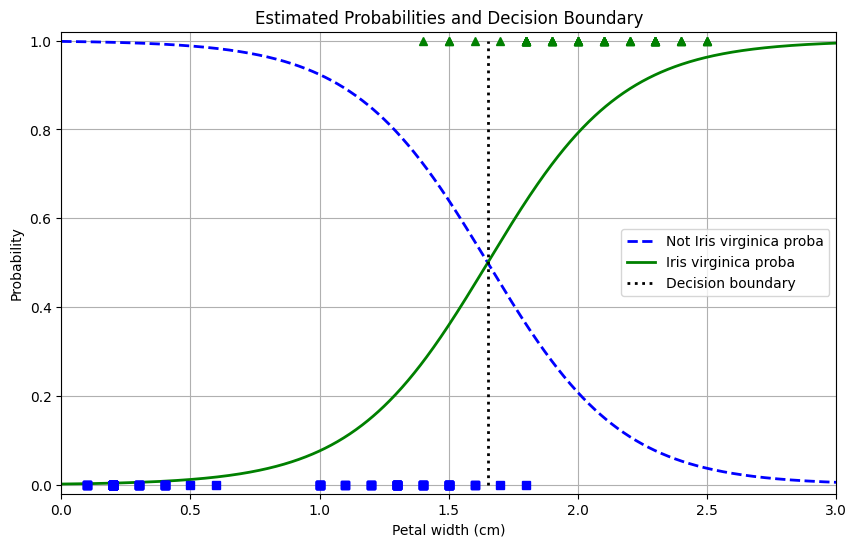

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")

plt.plot(X[y == 0], np.zeros_like(X[y == 0]), "bs")
plt.plot(X[y == 1], np.ones_like(X[y == 1]), "g^")

plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.xlim(0, 3)
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend()
plt.title("Estimated Probabilities and Decision Boundary")

plt.savefig("logistic_regression_binary.png", dpi=300, bbox_inches="tight")
plt.show()

#Logistic regression

In [6]:
X_2 = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_2 = iris.target_names[iris.target] == "virginica"

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, random_state=42)

log_reg_2 = LogisticRegression(random_state=42)
log_reg_2.fit(X_train_2, y_train_2)

print("Train score:", log_reg_2.score(X_train_2, y_train_2))
print("Test score:", log_reg_2.score(X_test_2, y_test_2))

Train score: 0.9553571428571429
Test score: 1.0


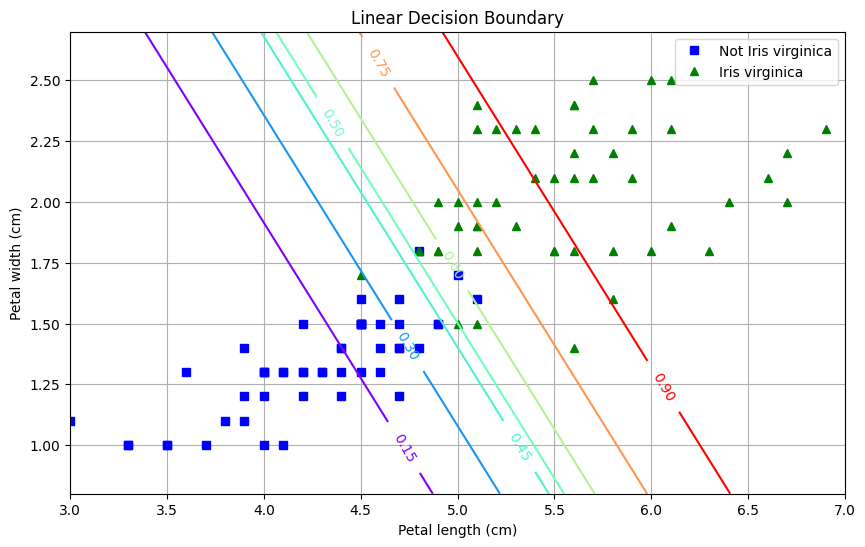

In [7]:
x0, x1 = np.meshgrid(
    np.linspace(3, 7, 500),
    np.linspace(0.8, 2.7, 500)
)
X_grid = np.c_[x0.ravel(), x1.ravel()]
y_proba_2 = log_reg_2.predict_proba(X_grid)[:, 1].reshape(x0.shape)

plt.figure(figsize=(10, 6))

plt.plot(X_2[y_2 == 0, 0], X_2[y_2 == 0, 1], "bs", label="Not Iris virginica")
plt.plot(X_2[y_2 == 1, 0], X_2[y_2 == 1, 1], "g^", label="Iris virginica")

contour = plt.contour(x0, x1, y_proba_2, levels=[0.15, 0.30, 0.45, 0.50, 0.60, 0.75, 0.90], cmap="rainbow")
plt.clabel(contour, inline=True, fontsize=10)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.xlim(3, 7)
plt.ylim(0.8, 2.7)
plt.grid(True)
plt.legend()
plt.title("Linear Decision Boundary")

plt.savefig("logistic_regression_linear_boundary.png", dpi=300, bbox_inches="tight")
plt.show()

#Softmax regression

In [9]:
X_soft = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_soft = iris["target"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_soft, y_soft, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train_s, y_train_s)

print("Train score:", softmax_reg.score(X_train_s, y_train_s))
print("Test score:", softmax_reg.score(X_test_s, y_test_s))

Train score: 0.9464285714285714
Test score: 1.0


In [10]:
print(softmax_reg.predict([[5, 2]]))
print(softmax_reg.predict_proba([[5, 2]]).round(2))

[2]
[[0.   0.04 0.96]]


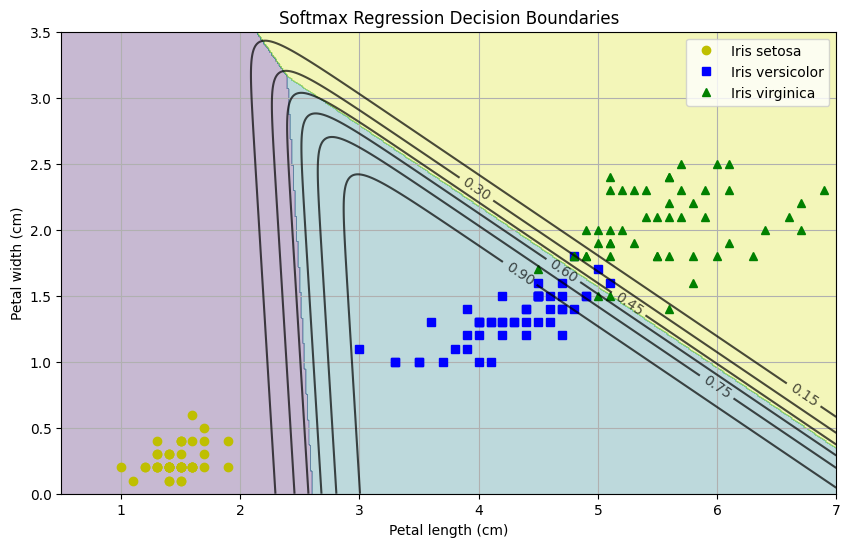

In [11]:
x0, x1 = np.meshgrid(
    np.linspace(0.5, 7, 500),
    np.linspace(0, 3.5, 500)
)
X_grid_soft = np.c_[x0.ravel(), x1.ravel()]
y_predict_soft = softmax_reg.predict(X_grid_soft).reshape(x0.shape)
y_proba_soft = softmax_reg.predict_proba(X_grid_soft)

plt.figure(figsize=(10, 6))

plt.contourf(x0, x1, y_predict_soft, alpha=0.3)

plt.plot(X_soft[y_soft == 0, 0], X_soft[y_soft == 0, 1], "yo", label="Iris setosa")
plt.plot(X_soft[y_soft == 1, 0], X_soft[y_soft == 1, 1], "bs", label="Iris versicolor")
plt.plot(X_soft[y_soft == 2, 0], X_soft[y_soft == 2, 1], "g^", label="Iris virginica")

versicolor_proba = y_proba_soft[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, versicolor_proba, levels=[0.15, 0.30, 0.45, 0.60, 0.75, 0.90], colors="k", alpha=0.7)
plt.clabel(contour, inline=True, fontsize=10)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.xlim(0.5, 7)
plt.ylim(0, 3.5)
plt.grid(True)
plt.legend()
plt.title("Softmax Regression Decision Boundaries")

plt.savefig("softmax_regression.png", dpi=300, bbox_inches="tight")
plt.show()